# Fungi Images Classification (Edible & Non-Edible)

In [2]:
!pip install opendatasets

## Library

In [3]:
import os
import opendatasets as od
import cv2 #read image dataset
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adamax

## Load Datasets

In [4]:
od.download('https://www.kaggle.com/datasets/marcosvolpato/edible-and-poisonous-fungi/data')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: {"username":"gigihbaliputra","key":"35048af2611b9f31f8877f733d37dad7"}
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/marcosvolpato/edible-and-poisonous-fungi


100%|██████████| 257M/257M [00:01<00:00, 254MB/s]

In [8]:
os.listdir('/content/edible-and-poisonous-fungi')

['poisonous_ms', 'poisonous_s', 'edible_ms', 'edible_s', '.ipynb_checkpoints']

In [47]:
data_folder_path = '/content/edible-and-poisonous-fungi'
classes = ['edible_ms', 'poisonous_ms']
label_map = {sub: i for i, sub in enumerate(classes)}

#list
images = []
labels = []

#resizing images iteration
for sub in classes:
  sub_path = os.path.join(data_folder_path, sub)
  for filename in os.listdir(sub_path):
    img_path = os.path.join(sub_path, filename)
    #read images
    img = cv2.imread(img_path)
    if img is not None:
      resized = cv2.resize(img, (64, 64))
      images.append(resized)
      labels.append(label_map[sub])

#convert to arrays
images = np.array(images)
labels = np.array(labels)

In [45]:
label_map

{'edible_ms': 0, 'poisonous_ms': 1}

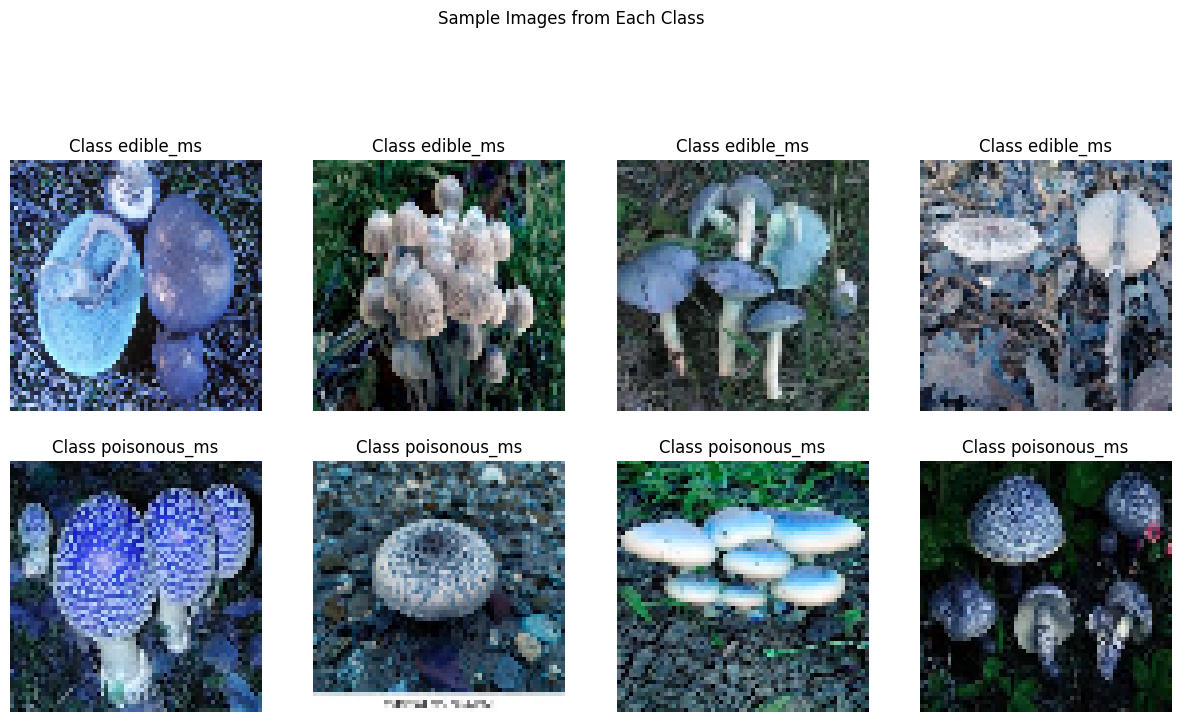

In [48]:
plt.figure(figsize = (15,15))
for i, label in enumerate(classes):
    class_indices = np.where(labels == label_map[label])[0]
    for j in range(4):
        plt.subplot(4, 4, i*4 + j+1)
        plt.imshow(images[class_indices[j]])
        plt.title(f"Class {label}")
        plt.axis('off')
plt.suptitle('Sample Images from Each Class')
plt.show()

## Pre-processing

In [49]:
#split data train & temp
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.3, random_state=42)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Train set: (1102, 64, 64, 3)
Test set: (473, 64, 64, 3)


In [50]:
#Normalizing
X_train = X_train / 255.0
X_test = X_test / 255.0

## Modelling

In [55]:
cnn = Sequential([
    #layer 1
    Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(pool_size=(2,2)),
    #layer 2
    Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='sigmoid')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [56]:
cnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,922 (3.14 MB)

 Trainable params: 822,922 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:
#model compile
cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

#callback
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_model.keras',
    save_best_only=True,
    monitor='val_loss',
)

In [58]:
cnn.fit(X_train, y_train, epochs=10, callbacks=[callback, model_checkpoint])

Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.4869 - loss: 1.0879

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):


35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 193ms/step - accuracy: 0.4882 - loss: 1.0822
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 202ms/step - accuracy: 0.5733 - loss: 0.6695
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 170ms/step - accuracy: 0.6892 - loss: 0.5975
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 215ms/step - accuracy: 0.7148 - loss: 0.5351
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 172ms/step - accuracy: 0.7309 - loss: 0.5343
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - accuracy: 0.7725 - loss: 0.4774
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 215ms/step - accuracy: 0.7990 - loss: 0.4289
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 172ms/step - accuracy: 0.8411 - loss: 0.3192
Epoch 9/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 216ms/step - accuracy: 0.8629 - loss: 0.3111
Epoch 10/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 175ms/step - accuracy: 0.8656 - loss: 0.2235


## Model Evaluation

In [59]:
cnn.evaluate(X_test, y_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.5901 - loss: 0.8888


[0.8199788928031921, 0.5983086824417114]

In [61]:
y_pred = cnn.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes, target_names=classes))

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step
              precision    recall  f1-score   support

   edible_ms       0.56      0.73      0.63       223
poisonous_ms       0.66      0.48      0.56       250

    accuracy                           0.60       473
   macro avg       0.61      0.61      0.60       473
weighted avg       0.61      0.60      0.59       473



Text(0.5, 1.0, 'Confusion Matrix')

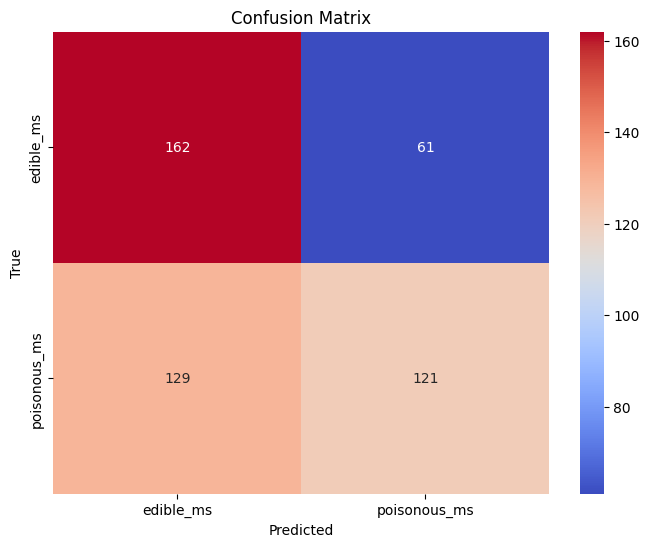

In [62]:
#heatmap visualization
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

In [ ]:
#plot train accuracy